<a href="https://colab.research.google.com/github/Victor-Castrol/projeto-2-cohort-churn/blob/main/01_exploracao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import kagglehub

path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Path to dataset files: /kaggle/input/online-retail-ii-uci


In [36]:
import pandas as pd

df = pd.read_csv(path + '/online_retail_II.csv')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [37]:
df.shape

(1067371, 8)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [39]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [40]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [41]:
df_limpo = df.copy()

df_limpo = df_limpo.dropna(subset=['Customer ID'])

df_limpo = df_limpo[df_limpo['Quantity'] > 0]

df_limpo = df_limpo[df_limpo['Price'] > 0]

df_limpo.shape

(805549, 8)

In [42]:
df_limpo['InvoiceDate'] = pd.to_datetime(df_limpo['InvoiceDate'])

df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[ns]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 55.3+ MB


In [43]:
df_limpo['MesCompra'] = df_limpo['InvoiceDate'].dt.to_period('M')

df_limpo['MesCohort'] = df_limpo.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')

df_limpo[['Customer ID', 'InvoiceDate', 'MesCompra', 'MesCohort']].head(10)

,Customer ID,InvoiceDate,MesCompra,MesCohort
0,13085.0,2009-12-01 07:45:00,2009-12,2009-12
1,13085.0,2009-12-01 07:45:00,2009-12,2009-12
2,13085.0,2009-12-01 07:45:00,2009-12,2009-12
3,13085.0,2009-12-01 07:45:00,2009-12,2009-12
4,13085.0,2009-12-01 07:45:00,2009-12,2009-12
5,13085.0,2009-12-01 07:45:00,2009-12,2009-12
6,13085.0,2009-12-01 07:45:00,2009-12,2009-12
7,13085.0,2009-12-01 07:45:00,2009-12,2009-12
8,13085.0,2009-12-01 07:46:00,2009-12,2009-12
9,13085.0,2009-12-01 07:46:00,2009-12,2009-12


In [44]:
df_limpo[df_limpo['Customer ID'] == 13085][['InvoiceDate', 'MesCompra', 'MesCohort']].drop_duplicates(subset='MesCompra')

,InvoiceDate,MesCompra,MesCohort
0,2009-12-01 07:45:00,2009-12,2009-12
74247,2010-01-29 10:06:00,2010-01,2009-12
619157,2011-02-17 13:57:00,2011-02,2009-12
775532,2011-07-05 12:11:00,2011-07,2009-12


In [45]:
df_limpo['IndiceCohort'] = (df_limpo['MesCompra'] - df_limpo['MesCohort']).apply(lambda x: x.n)

In [46]:
cohort_contagem = df_limpo.groupby(['MesCohort', 'IndiceCohort'])['Customer ID'].nunique().reset_index()

cohort_contagem.head(10)

,MesCohort,IndiceCohort,Customer ID
0,2009-12,0,955
1,2009-12,1,337
2,2009-12,2,319
3,2009-12,3,406
4,2009-12,4,363
5,2009-12,5,343
6,2009-12,6,360
7,2009-12,7,327
8,2009-12,8,321
9,2009-12,9,346


In [47]:
cohort_tabela = cohort_contagem.pivot(index='MesCohort', columns='IndiceCohort', values='Customer ID')

cohort_tabela

IndiceCohort,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
MesCohort,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
tamanho_cohort = cohort_tabela.iloc[:, 0]

retencao = cohort_tabela.divide(tamanho_cohort, axis=0)

retencao.round(3).head()

IndiceCohort,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
MesCohort,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,...,0.303,0.263,0.303,0.283,0.260,0.255,0.315,0.305,0.407,0.197
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,...,0.151,0.235,0.198,0.185,0.196,0.243,0.193,0.245,0.057,NaN
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286,0.254,0.275,...,0.201,0.160,0.163,0.144,0.230,0.230,0.163,0.059,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.108,...,0.169,0.174,0.156,0.176,0.201,0.212,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.105,0.109,...,0.156,0.139,0.150,0.180,0.224,0.058,NaN,NaN,NaN,NaN


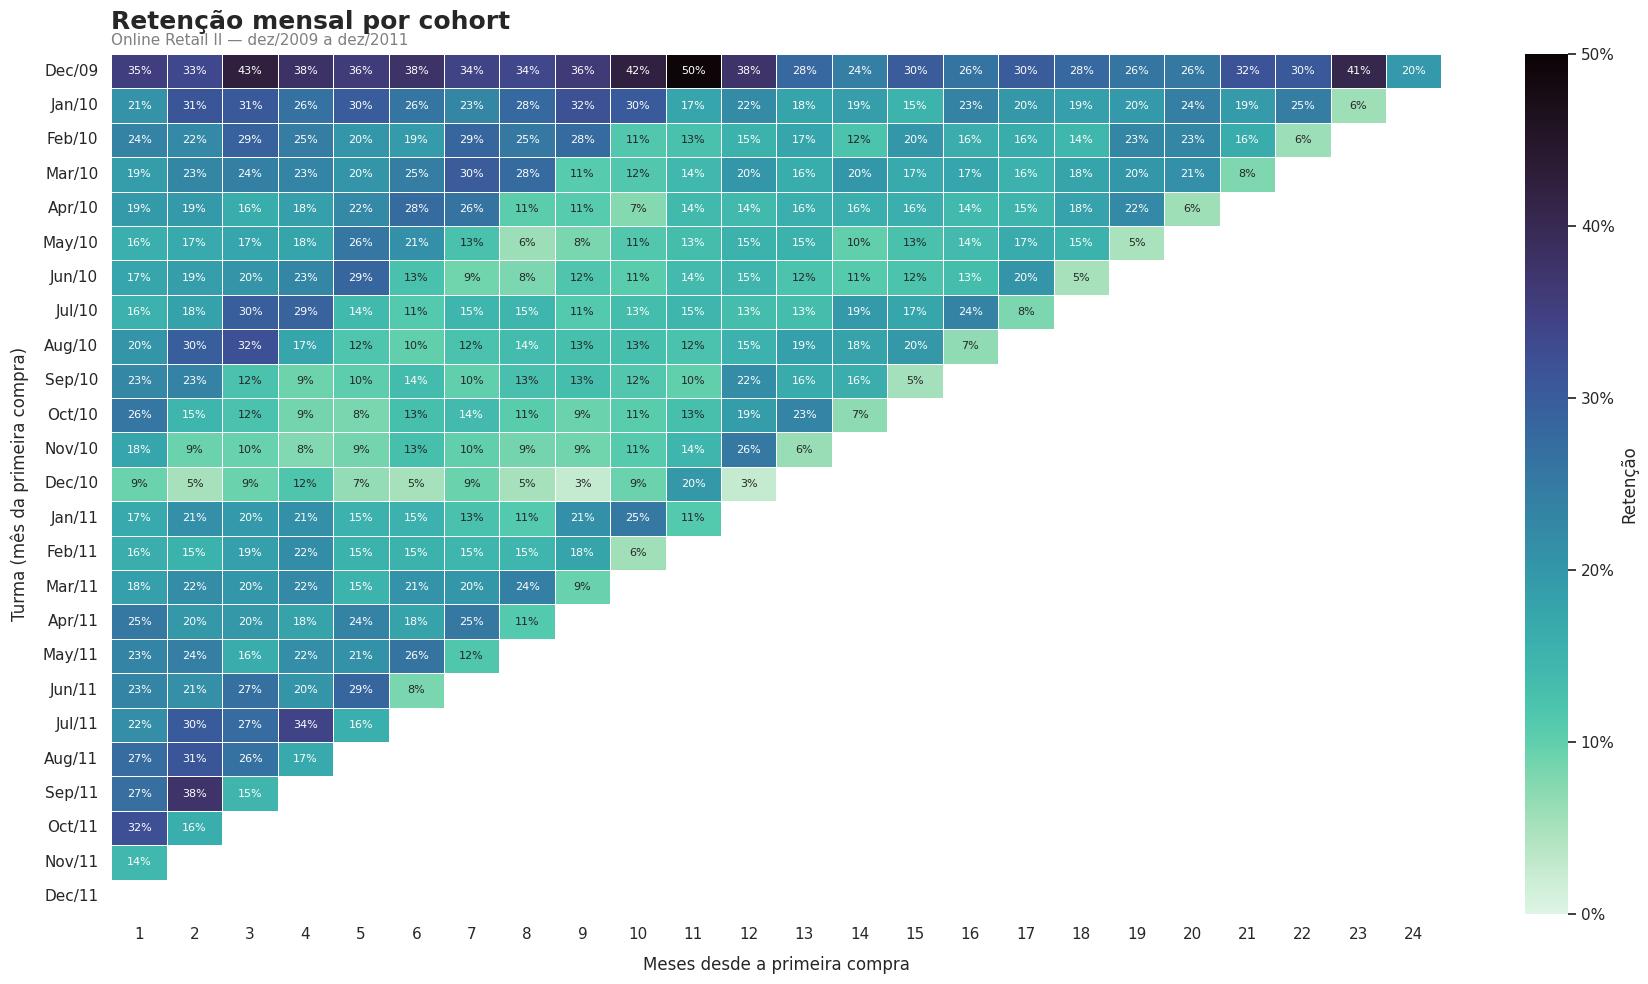

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='white')

retencao_plot = retencao.copy().drop(columns=0)
retencao_plot.index = retencao_plot.index.strftime('%b/%y')

fig, ax = plt.subplots(figsize=(18, 10))

sns.heatmap(
    retencao_plot,
    annot=True,
    fmt='.0%',
    annot_kws={'fontsize': 8},
    cmap='mako_r',
    vmin=0, vmax=0.5,
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': 'Retenção', 'format': mtick.PercentFormatter(xmax=1)},
    ax=ax
)

ax.set_title('Retenção mensal por cohort', fontsize=18, fontweight='bold', loc='left', pad=18)
ax.text(0, 1.01, 'Online Retail II — dez/2009 a dez/2011', transform=ax.transAxes,
        fontsize=11, color='gray')

ax.set_xlabel('Meses desde a primeira compra', fontsize=12, labelpad=10)
ax.set_ylabel('Turma (mês da primeira compra)', fontsize=12, labelpad=10)

ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('heatmap_retencao.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
df_limpo['Receita'] = df_limpo['Quantity'] * df_limpo['Price']

In [51]:
data_referencia = df_limpo['InvoiceDate'].max()

rfm = df_limpo.groupby('Customer ID').agg(
    Recencia=('InvoiceDate', lambda x: (data_referencia - x.max()).days),
    Frequencia=('Invoice', 'nunique'),
    Valor=('Receita', 'sum')
).reset_index()

rfm.head()

,Customer ID,Recencia,Frequencia,Valor
0,12346.0,325,12,77556.46
1,12347.0,1,8,5633.32
2,12348.0,74,5,2019.40
3,12349.0,18,4,4428.69
4,12350.0,309,1,334.40


In [52]:
rfm.shape

(5878, 4)

In [53]:
rfm.describe().round(1)

,Customer ID,Recencia,Frequencia,Valor
count,5878.0,5878.0,5878.0,5878.0
mean,15315.3,200.3,6.3,3018.6
std,1715.6,209.3,13.0,14737.7
min,12346.0,0.0,1.0,3.0
25%,13833.2,25.0,1.0,348.8
50%,15314.5,95.0,3.0,898.9
75%,16797.8,379.0,7.0,2307.1
max,18287.0,738.0,398.0,608821.6


In [54]:
data_corte = df_limpo['InvoiceDate'].max() - pd.Timedelta(days=90)

df_passado = df_limpo[df_limpo['InvoiceDate'] <= data_corte]
df_futuro = df_limpo[df_limpo['InvoiceDate'] > data_corte]

print('Data de corte:', data_corte)
print('Linhas no passado:', df_passado.shape[0])
print('Linhas no futuro:', df_futuro.shape[0])

Data de corte: 2011-09-10 12:50:00
Linhas no passado: 644022
Linhas no futuro: 161527


In [55]:
data_ref_passado = df_passado['InvoiceDate'].max()

rfm_modelo = df_passado.groupby('Customer ID').agg(
    Recencia=('InvoiceDate', lambda x: (data_ref_passado - x.max()).days),
    Frequencia=('Invoice', 'nunique'),
    Valor=('Receita', 'sum')
).reset_index()

clientes_futuro = df_futuro['Customer ID'].unique()

rfm_modelo['Churn'] = (~rfm_modelo['Customer ID'].isin(clientes_futuro)).astype(int)

rfm_modelo['Churn'].value_counts()

,count
Churn,
1,2989
0,2292


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = rfm_modelo[['Recencia', 'Frequencia', 'Valor']]
y = rfm_modelo['Churn']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = RandomForestClassifier(n_estimators=300, random_state=42)
modelo.fit(X_treino, y_treino)

print('Clientes no treino:', X_treino.shape[0])
print('Clientes no teste:', X_teste.shape[0])

Clientes no treino: 3960
Clientes no teste: 1321


In [58]:
from sklearn.metrics import accuracy_score, confusion_matrix

previsoes = modelo.predict(X_teste)

print('Acurácia:', round(accuracy_score(y_teste, previsoes), 3))

print(confusion_matrix(y_teste, previsoes))

Acurácia: 0.697
[[345 228]
 [172 576]]


In [59]:
import pandas as pd

importancias = pd.Series(modelo.feature_importances_, index=X.columns)

importancias.sort_values(ascending=False)

,0
Valor,0.437808
Recencia,0.423274
Frequencia,0.138917
